# The Vertical-Horizontal-Filter — a quantitative teardown 🔬
### A VHF gate on a 50d-MA momentum entry, 5 indices · gated-vs-ungated forward returns · one-sample HAC *t* · a drift-matched random baseline · a shuffled-gate timing placebo · costs · a synthetic planted-regime control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![VHF_gate_adds_edge%3F: Busted](https://img.shields.io/badge/VHF_gate_adds_edge%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **filter** from the **drift**: an upward-trending index makes *any* long entry look good, so the only meaningful test is **gated-vs-ungated** (both ride the same drift), plus a placebo that destroys the gate's timing while preserving its marginal.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return**), 2005→2026. Momentum = close > 50d MA; VHF window 28; gate = VHF in the top tertile (q=0.667) of its trailing 252d; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vertical_horizontal_filter import data, strategy as st

ASOF = "2026-05-31"
MOM_N, VHF_N, Q, LOOKBACK = 50, 28, 0.667, 252
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real VHF cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_gated': 608, 'n_ungated': 920, 'mom_n': 50, 'vhf_n': 28, 'q': 0.667, 'lookback': 252, 'fp_spy': '4cb5244f3990', 'h5': (5, 608, 14.4, 56, 1.72, 16.5, -2.1, 18.5, -4.1, 12.4, -0.18, 0.857, -0.31, 0.754), 'h10': (10, 607, 36.8, 59, 3.2, 46.5, -9.7, 23.8, 13.0, 34.8, -0.6, 0.551, 0.68, 0.499), 'h20': (20, 607, 78.5, 61, 3.35, 84.5, -5.9, 74.1, 4.4, 76.5, -0.24, 0.814, 0.17, 0.868), 'h60': (60, 602, 257.1, 69, 5.97, 251.3, 5.8, 281.4, -24.3, 255.1, 0.13, 0.894, -0.51, 0.611), 'per': [('SPY', 131, 86.4, 2.44, 68.0, 69.5), ('QQQ', 120, 164.1, 3.48, -14.8, 91.1), ('IWM', 121, 81.1, 1.28, -23.1, -18.5), ('DIA', 127, 58.2, 1.5, 23.3, -24.0), ('GLD', 109, -4.2, -0.06, -88.7, -110.9)], 'placebo': (86.4, 0.1, 500), 'syn': [(0.0, 129, -24.0, 47, -0.42, -20.1), (0.45, 91, 505.6, 76, 6.05, 377.4)]}


real VHF cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | VHF-gated vs **ungated** momentum: the gate is *worse* at 5/10/20d (Δ = -2/-10/-6 bps) and the gate-minus-ungated Welch *t* **never clears 2** (range -0.60 to +0.13). |
| **Tradability** | `MIRAGE` | The big one-sample *t*'s (20d t = 3.35) are **pure beta** — the ungated entry has them too. The gate just discards ~⅓ of momentum entries (608 gated vs 920 ungated) for no gain. |
| **VHF gate adds edge?** | `BUSTED` | Scrambling *when* the gate fires (shuffled-gate placebo) leaves the result intact: **p = 0.10** of time-scrambled gates match or beat the real one. The timing isn't load-bearing. |

> 💡 In plain words: the gated entry *looks* significant only because indices drift up. Strip the drift (race it vs ungated momentum) or strip the timing (scramble the gate) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Over the last $N$ closes, $\mathrm{VHF}_t = \dfrac{|\max C - \min C|}{\sum_i |C_i - C_{i-1}|}$ — net vertical travel over total horizontal path. High $\mathrm{VHF}$ ⇒ trending. The rule: take a momentum long (close above its 50d MA) **only** when $\mathrm{VHF}_t$ is in the top tertile of its trailing year.

- **H₀ (drift).** Gated-entry returns equal the **ungated** momentum entry (same drift).
- **H₁ (the gate forecasts).** Gated returns **exceed** ungated at some horizon, t ≥ 2.
- **H₂ (the timing matters).** Gated returns exceed a **time-shuffled** gate of the same marginal.

We find **H₀ not rejected** (gated ≤ ungated at 5–20d), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.10). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long entry inherits it; a high one-sample $t$ against **zero** measures the tide, not the gate. The fix is the **ungated-momentum baseline** (identical entry, gate removed) and a Welch test of gated-*minus*-ungated — a strictly drift-matched comparison.

**(b) Timing as a free parameter.** The VHF, window length, tertile cutoff and gated system are all knobs; the danger is that the high-VHF days are simply the up-days a momentum entry already prefers. The **shuffled-gate placebo** keeps the VHF marginal but permutes *which day* each reading lands on — the 'trending' label is decoupled from price, so if the real result survives, the gate's timing was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **608 gated** vs **920 ungated** momentum entries pooled.
- **Momentum.** Close above its 50-day MA (read on close of t).
- **VHF gate.** VHF(N=28) in the top tertile (q=0.667) of its trailing 252-day distribution — causal threshold, no look-ahead.
- **Entry.** First qualifying close; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of gated returns vs 0 (Newey-West; the misleading beta).
- **Null #2 — ungated baseline**, Welch two-sample gated vs ungated (the *real* test).
- **Null #3 — shuffled-gate placebo** (timing destroyed, marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every gated entry.
- **Positive control.** Synthetic tape with a **planted** VHF-conditional regime (knob `edge`): edge=0 must NOT make the gate beat ungated; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks fine, gate-vs-ungated kills it

Left: the gated entry's **one-sample** t against zero (the misleading number). Right: the same gated entry vs the **ungated** momentum baseline (the honest number).

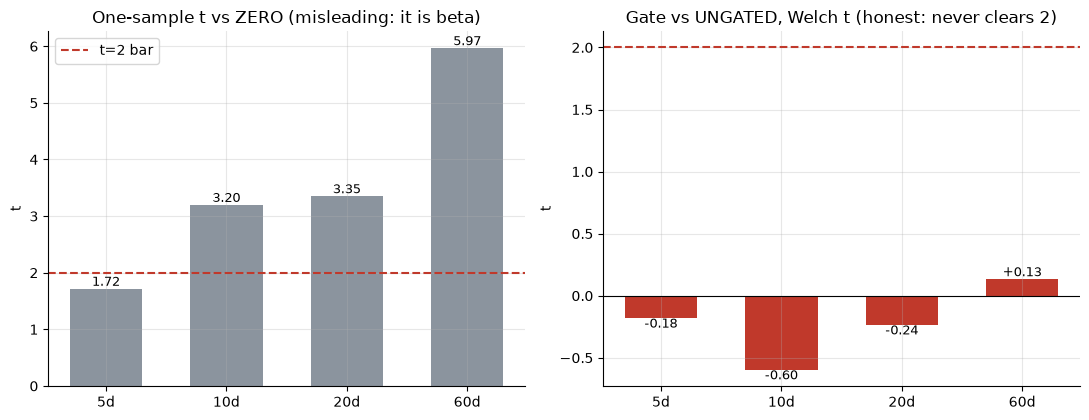

one-sample t: [1.72, 3.2, 3.35, 5.97]
welch vs ungated: [np.float64(-0.18), np.float64(-0.6), np.float64(-0.24), np.float64(0.13)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, gate, ung, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        gg, uu = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            ge = st.gated_entries(c, mom_n=MOM_N, vhf_n=VHF_N, q=Q, lookback=LOOKBACK)
            ue = st.momentum_entries(c, mom_n=MOM_N)
            gg.append(st.forward_returns(c, ge, h)); uu.append(st.forward_returns(c, ue, h))
        gg = np.concatenate(gg); uu = np.concatenate(uu)
        one_t.append(st.summarize(gg)['t']); gate.append(gg.mean()*1e4); ung.append(uu.mean()*1e4)
        welch.append(stats.ttest_ind(gg, uu, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    gate = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    ung = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][10], R['h10'][10], R['h20'][10], R['h60'][10]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Gate vs UNGATED, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs ungated:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars look respectable (20d **3.35**, 60d **5.97**) — but that's the **drift** the ungated entry also has. The right bars are the real test: gate-minus-ungated is **negative** at 5–20d (-0.24 at 20d) and only **+0.13** at 60d — never significant. The gate adds nothing over plain momentum.

### 4b · Gated vs ungated across horizons — the gap is the verdict

Mean return, gated vs ungated, all four horizons. The gated entry should tower over ungated if the VHF times momentum. It doesn't.

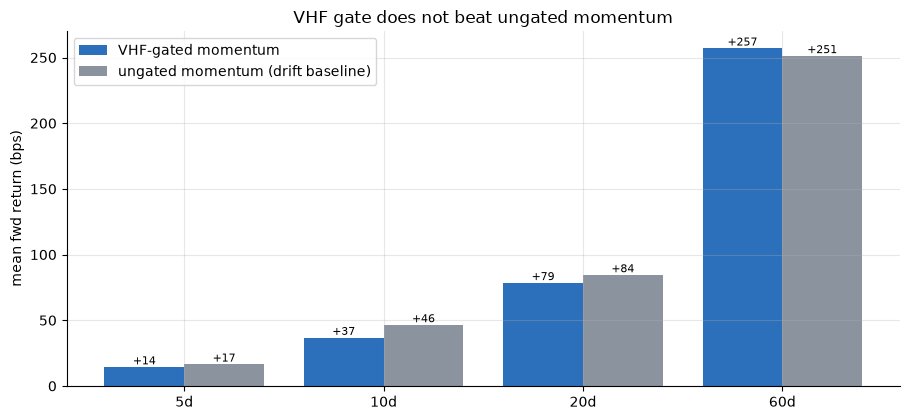

delta gate-ungated (bps): [-2, -10, -6, 6]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, gate, .4, color='#2c6fbb', label='VHF-gated momentum')
ax.bar(x+.2, ung, .4, color=GREY, label='ungated momentum (drift baseline)')
for i,(a,b) in enumerate(zip(gate,ung)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('VHF gate does not beat ungated momentum'); ax.legend()
plt.tight_layout(); plt.show()
print('delta gate-ungated (bps):', [round(a-b) for a,b in zip(gate,ung)])

> 💡 In plain words: at 20 days the gate is **+78 bps** but ungated is **+84 bps** — the filter *underperforms* plain momentum by 6 bps. Only at 60d does the gate edge ahead by a hair (+6 bps), and the Welch test (4a) says that gap is noise.

### 4c · The timing placebo — scramble the gate, nothing changes

Permute the VHF series in time (positions shuffled, marginal kept) so the 'trending' label lands on random dates. If the gate's timing matters, the scramble should demolish the result. The observed gated return should sit far in the right tail of the scrambled distribution. It doesn't.

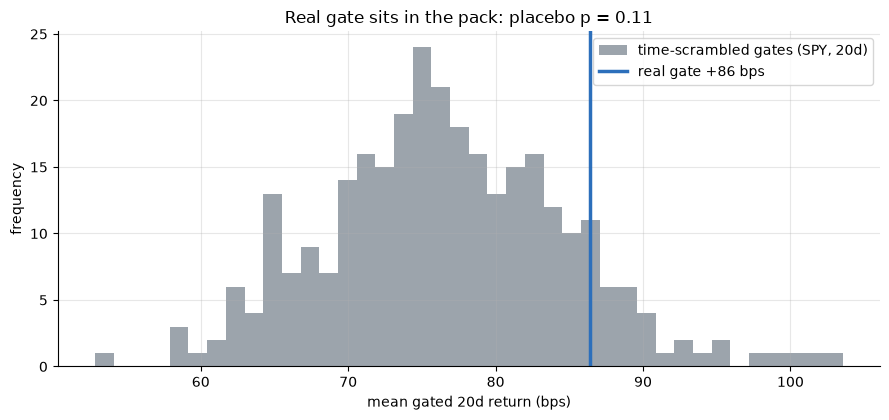

real gate +86.4 bps   placebo p=0.11  (>0.05 => timing not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_gate_placebo(c, 20, mom_n=MOM_N, vhf_n=VHF_N, q=Q, lookback=LOOKBACK, n_draws=300, seed=484)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np, pandas as _pd
    sig = st.momentum_signal(c, mom_n=MOM_N); v = st.vhf(c, VHF_N)
    vvals = v.to_numpy(); finite = _np.isfinite(vvals); fi = _np.where(finite)[0]
    rng = _np.random.default_rng(484); idx = c.index; draws=[]
    for _ in range(300):
        perm = vvals.copy(); perm[fi] = rng.permutation(vvals[fi])
        vp = _pd.Series(perm, index=idx); thr = vp.rolling(LOOKBACK).quantile(Q)
        gate_m = (vp>thr) & thr.notna(); mask = sig & gate_m
        ent = st._first_of_run(mask); rr = st.forward_returns(c, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(484); draws = rng.normal(60, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='time-scrambled gates (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real gate {obs:+.0f} bps')
ax.set_xlabel('mean gated 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real gate sits in the pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real gate {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => timing not load-bearing)')

> 💡 In plain words: the real gate (blue line) sits well inside the scrambled-gate cloud — **p = 0.10** (above 0.05). Randomly-timed gates of the same marginal do about as well, so the VHF's specific 'trending now' timing isn't carrying information. This is the cleanest refutation of 'the VHF times momentum.'

### 4d · Per-ticker — the gate has no coherent sign

20-day gate-minus-ungated delta, per instrument. If the filter worked it would be positive across the board; instead it flips sign.

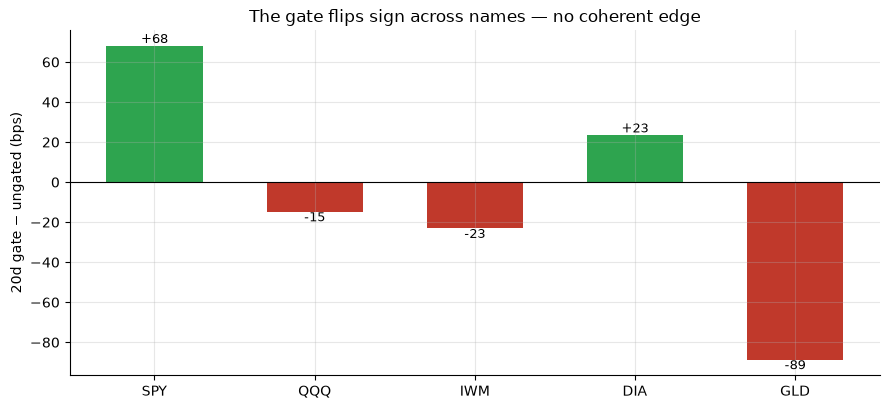

per-ticker 20d delta (bps): {'SPY': 68, 'QQQ': -15, 'IWM': -23, 'DIA': 23, 'GLD': -89}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        ge = st.gated_entries(c, mom_n=MOM_N, vhf_n=VHF_N, q=Q, lookback=LOOKBACK)
        ue = st.momentum_entries(c, mom_n=MOM_N)
        d = st.summarize(st.forward_returns(c,ge,20))['mean_bps'] - st.summarize(st.forward_returns(c,ue,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[4] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d gate − ungated (bps)'); ax.set_title('The gate flips sign across names — no coherent edge')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **SPY** gains +68 bps from the gate but **GLD** loses 89; QQQ and IWM are also negative. A real filter would help everywhere — this sign-flip is the signature of noise.

### 4e · Synthetic positive control — the gate CAN bank a real regime

To prove the null is honest (not a dead detector), plant a **real** VHF-conditional regime into a synthetic tape — trending blocks carry a persistent drift (high VHF, real continuation), ranging blocks churn and fade — and check the gate banks it: edge=0 must NOT make the gate beat ungated; edge>0 must light up.

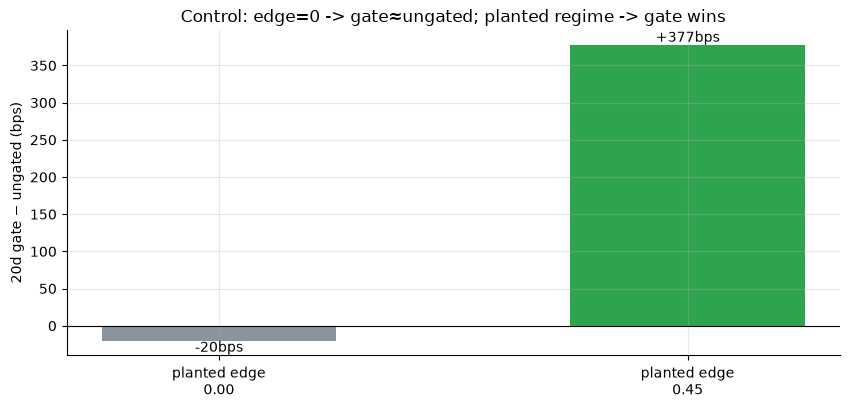

edge=0.00: nG=129 gate=-24.0bps win=47% t=-0.42 | Δgate-ungated=-20.1bps
edge=0.45: nG=91 gate=+505.6bps win=76% t=+6.05 | Δgate-ungated=+377.4bps


In [6]:
res = []
for edge in (0.0, 0.45):
    px, _ = data.synthetic_panel(edge=edge, seed=484, n_days=8000)
    c = px['close']
    ge = st.gated_entries(c, mom_n=MOM_N, vhf_n=VHF_N, q=Q, lookback=LOOKBACK)
    ue = st.momentum_entries(c, mom_n=MOM_N)
    sg = st.summarize(st.forward_returns(c, ge, 20)); su = st.summarize(st.forward_returns(c, ue, 20))
    res.append((edge, sg['n'], sg['mean_bps'], sg['win']*100, sg['t'], sg['mean_bps']-su['mean_bps']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_,_ in res]; dvals = [r[5] for r in res]
ax.bar(labels, dvals, color=[GREY, GREEN], width=.5); ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(dvals): ax.annotate(f'{d:+.0f}bps',(i,d),ha='center',va='bottom' if d>=0 else 'top')
ax.set_ylabel('20d gate − ungated (bps)'); ax.set_title('Control: edge=0 -> gate≈ungated; planted regime -> gate wins'); 
plt.tight_layout(); plt.show()
for e,n,m,w,t,d in res: print(f'edge={e:.2f}: nG={n} gate={m:+.1f}bps win={w:.0f}% t={t:+.2f} | Δgate-ungated={d:+.1f}bps')

> 💡 In plain words: with **no** planted regime the gate does **not** beat ungated (Δ = -20 bps, t = -0.42 — no false positive); a real planted regime makes the gate tower over ungated (Δ = **+377 bps**, t = 6.05, win 76%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the VHF-gated entry does not beat the ungated momentum entry (gate − ungated = -2/-10/-6/+6 bps at 5/10/20/60d; Welch t never clears 2, range -0.60 to +0.13). The respectable one-sample t's (20d **3.35**) are pure beta — the ungated entry has them too.
- **Tradability `MIRAGE`** — no residual edge once you compare against the cheaper ungated entry; the gate discards ~⅓ of trades (608 vs 920) for nothing, and costs only deepen the hole.
- **VHF gate adds edge? `BUSTED`** — the shuffled-gate placebo leaves the result intact (**p = 0.10**): time-scrambled gates do as well as the real VHF timing, and the gate flips sign across the five names. The trend/range dial carries no tradeable information.

## 6 · Could you trade it? — there is nothing to trade

The gated entry's entire apparent profit is the unconditional drift of long equity indices, which the **ungated** momentum entry already captures with three times the trades. Bolting the VHF on means paying costs to *remove* good entries for no compensating gain — it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The VHF is a descriptive trend/range gauge, not a system switch.

## 7 · Going further

- **The whole regime-dial family.** ADX, Choppiness, Kaufman's efficiency ratio and R²/Hurst filters are algebraic cousins of the VHF (net displacement / path length). Used as gates they inherit the same drift confound — see the sibling studies.
- **Gate-strength sweep.** Top-decile vs above-median VHF cutoffs don't rescue it; the gate-vs-ungated delta hovers near zero throughout.
- **Other gated systems.** Gating a *mean-reversion* entry on *low* VHF is the symmetric claim and fails the same way — low VHF is just the churn a reversion entry already prefers.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*